# 📊 Baseline Models — Feature-Only Fraud Detection

**Goal:** Train non-graph baseline classifiers that treat each transaction **independently** (ignoring graph structure). These establish the performance floor that GNNs must beat.

**Why baselines matter:**
- If a simple model already achieves high F1, the added complexity of GNNs may not be justified
- Baselines reveal how much signal is in the **node features** alone vs the **graph structure**
- The gap between baseline and GNN performance quantifies the value of graph-based learning

---

### Models

| Model | Type | Handles Imbalance? | Uses Graph? |
|-------|------|:------------------:|:-----------:|
| Logistic Regression | Linear | ✓ (class_weight) | ✗ |
| XGBoost | Gradient Boosted Trees | ✓ (scale_pos_weight) | ✗ |
| Random Forest | Ensemble Trees | ✓ (class_weight) | ✗ |

---

### Notebook Structure

| # | Section | Purpose |
|---|---------|---------|
| 1 | Imports & Config | Load libraries |
| 2 | Load Processed Data | Load saved PyG graph, extract arrays |
| 3 | Extract Train/Test Arrays | Mask → NumPy arrays |
| 4 | Evaluation Utilities | F1, PR-AUC, confusion matrix, PR curve functions |
| 5 | Logistic Regression | Train + evaluate |
| 6 | XGBoost | Train + evaluate |
| 7 | Random Forest | Train + evaluate |
| 8 | Model Comparison Table | Side-by-side metrics |
| 9 | PR Curve Overlay | All baselines on one plot |
| 10 | Feature Importance (XGBoost) | Top features by gain |
| 11 | Key Takeaways | Summary + motivation for GNNs |

---
## 1. Imports & Config

**Libraries:**
- `sklearn` — Logistic Regression, Random Forest, metrics
- `xgboost` — gradient boosted trees
- `torch` — load PyG data
- `matplotlib`, `seaborn` — visualization

In [11]:
import os
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, accuracy_score
)
from xgboost import XGBClassifier

# Config
warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", context="notebook", font_scale=1.1)
PALETTE = {"Illicit": "#e74c3c", "Licit": "#2ecc71", "Unknown": "#95a5a6"}

PROCESSED_DIR = "../data/processed"
PLOT_DIR = "../results/plots/baseline"
os.makedirs(PLOT_DIR, exist_ok=True)

print("✅ Imports loaded")

✅ Imports loaded


---
## 2. Load Processed Data

**What:** Load the PyG `Data` object saved in Notebook 02.

**Expected contents:**
- `data.x` — normalized node features (203,769 × 166)
- `data.y` — labels (-1 = unknown, 0 = licit, 1 = illicit)
- `data.train_mask`, `data.val_mask`, `data.test_mask` — boolean split masks

In [12]:
data = torch.load(os.path.join(PROCESSED_DIR, "elliptic_graph.pt"), weights_only=False)

print(f"Loaded PyG Data object:")
print(f"  {data}")
print(f"  Nodes    : {data.x.size(0):,}")
print(f"  Features : {data.x.size(1)}")
print(f"  Edges    : {data.edge_index.size(1):,}")
print(f"  Train    : {data.train_mask.sum().item():,}")
print(f"  Val      : {data.val_mask.sum().item():,}")
print(f"  Test     : {data.test_mask.sum().item():,}")

Loaded PyG Data object:
  Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
  Nodes    : 203,769
  Features : 166
  Edges    : 234,355
  Train    : 32,594
  Val      : 6,984
  Test     : 6,986


---
## 3. Extract Train / Test Arrays

**What:** Convert PyG tensors to NumPy arrays for sklearn/XGBoost.

**Note:** For baseline models, we **ignore edges entirely** — each node is treated as an independent sample with 166 features. This is the key limitation that GNNs address.

In [13]:
# Convert to numpy
X = data.x.numpy()
y = data.y.numpy()
train_mask = data.train_mask.numpy()
val_mask = data.val_mask.numpy()
test_mask = data.test_mask.numpy()

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train set: {X_train.shape[0]:,} samples — Illicit: {(y_train == 1).sum():,}, Licit: {(y_train == 0).sum():,}")
print(f"Val   set: {X_val.shape[0]:,} samples — Illicit: {(y_val == 1).sum():,}, Licit: {(y_val == 0).sum():,}")
print(f"Test  set: {X_test.shape[0]:,} samples — Illicit: {(y_test == 1).sum():,}, Licit: {(y_test == 0).sum():,}")

Train set: 32,594 samples — Illicit: 3,197, Licit: 29,397
Val   set: 6,984 samples — Illicit: 673, Licit: 6,311
Test  set: 6,986 samples — Illicit: 675, Licit: 6,311


---
## 4. Evaluation Utilities

**What:** Define reusable functions for computing metrics and plotting.

**Metrics used:**
- **F1 Score (illicit class)** — harmonic mean of precision and recall for the minority class
- **PR-AUC** — area under the Precision-Recall curve (better than ROC-AUC for imbalanced data)
- **Confusion Matrix** — shows true/false positives/negatives

**Why not accuracy?** With ~9:1 class imbalance, a model that always predicts "licit" achieves ~90% accuracy. F1 and PR-AUC are much more informative.

In [14]:
def evaluate_model(model, X_test, y_test, model_name, plot=True):
    """
    Evaluate a classifier and return metrics dict.

    Returns:
        dict with keys: f1, pr_auc, accuracy, y_pred, y_prob
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # probability of illicit class

    f1 = f1_score(y_test, y_pred, pos_label=1)
    pr_auc = average_precision_score(y_test, y_prob, pos_label=1)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("=" * 60)
    print(f"  {model_name}")
    print("=" * 60)
    print(f"  F1 (illicit)   : {f1:.4f}")
    print(f"  PR-AUC         : {pr_auc:.4f}")
    print(f"  Accuracy       : {acc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Licit", "Illicit"]))

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Confusion matrix
        sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=axes[0],
                    xticklabels=["Licit", "Illicit"], yticklabels=["Licit", "Illicit"])
        axes[0].set_title(f"{model_name} — Confusion Matrix", fontsize=13, fontweight="bold")
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("Actual")

        # PR curve
        precision, recall, _ = precision_recall_curve(y_test, y_prob, pos_label=1)
        axes[1].plot(recall, precision, color=PALETTE["Illicit"], linewidth=2)
        axes[1].fill_between(recall, precision, alpha=0.2, color=PALETTE["Illicit"])
        axes[1].set_title(f"{model_name} — Precision-Recall Curve (AUC={pr_auc:.3f})",
                          fontsize=13, fontweight="bold")
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        axes[1].set_xlim([0, 1])
        axes[1].set_ylim([0, 1.05])

        fig.tight_layout()
        safe_name = model_name.lower().replace(" ", "_")
        fig.savefig(f"{PLOT_DIR}/{safe_name}_eval.png", dpi=150, bbox_inches="tight")
        plt.show()

    return {
        "model_name": model_name,
        "f1": f1,
        "pr_auc": pr_auc,
        "accuracy": acc,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "cm": cm
    }

print("✅ Evaluation utilities defined")

✅ Evaluation utilities defined


---
## 5. Logistic Regression

**What:** Train a simple linear classifier as the most basic baseline.

**Configuration:**
- `class_weight='balanced'` — automatically adjusts weights inversely proportional to class frequencies
- `max_iter=1000` — ensure convergence
- `solver='lbfgs'` — standard for binary classification

**Expected performance:** Decent but limited — linear models can't capture complex feature interactions.

✅ Logistic Regression trained (32,594 samples, 166 features)
  Logistic Regression
  F1 (illicit)   : 0.6022
  PR-AUC         : 0.7572
  Accuracy       : 0.8799

              precision    recall  f1-score   support

       Licit       0.99      0.87      0.93      6311
     Illicit       0.44      0.94      0.60       675

    accuracy                           0.88      6986
   macro avg       0.72      0.91      0.77      6986
weighted avg       0.94      0.88      0.90      6986



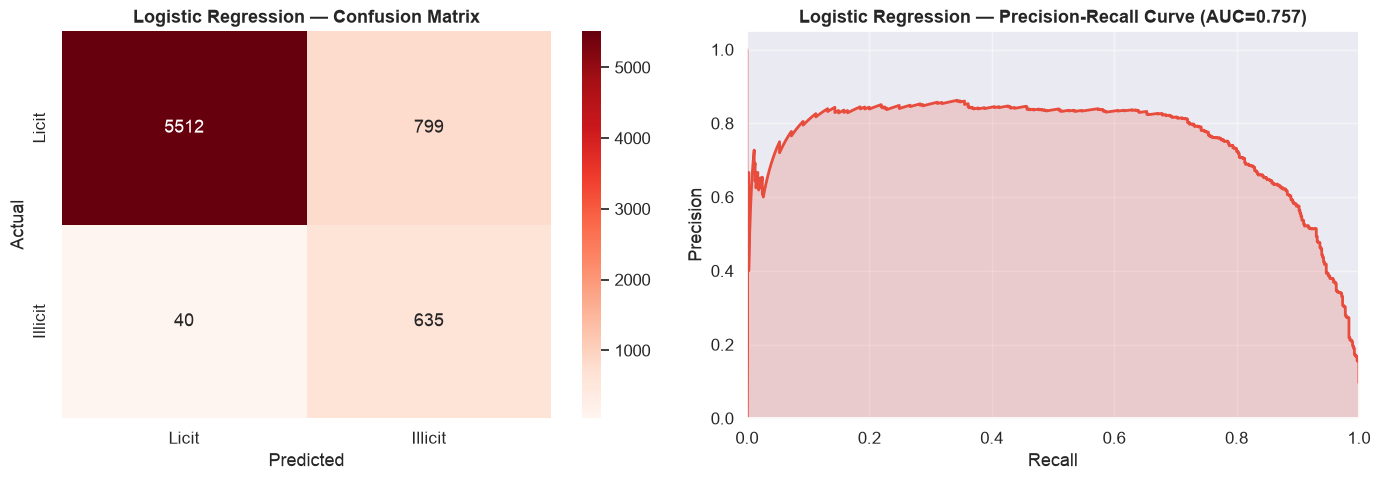

In [15]:
# Train Logistic Regression
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs",
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train, y_train)
print(f"✅ Logistic Regression trained ({X_train.shape[0]:,} samples, {X_train.shape[1]} features)")

# Evaluate
lr_results = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")

---
## 6. XGBoost

**What:** Train a gradient boosted tree classifier — the gold standard for tabular data.

**Configuration:**
- `scale_pos_weight` — ratio of licit to illicit counts (handles imbalance)
- `max_depth=6` — moderate tree depth
- `n_estimators=200` — number of boosting rounds
- `learning_rate=0.1` — step size shrinkage
- `eval_metric='aucpr'` — optimize for PR-AUC during training

**Expected performance:** Strong — XGBoost typically excels on tabular features. This is the baseline to beat.

scale_pos_weight: 9.20
✅ XGBoost trained (32,594 samples)
  XGBoost
  F1 (illicit)   : 0.9544
  PR-AUC         : 0.9865
  Accuracy       : 0.9913

              precision    recall  f1-score   support

       Licit       0.99      1.00      1.00      6311
     Illicit       0.96      0.95      0.95       675

    accuracy                           0.99      6986
   macro avg       0.98      0.97      0.97      6986
weighted avg       0.99      0.99      0.99      6986



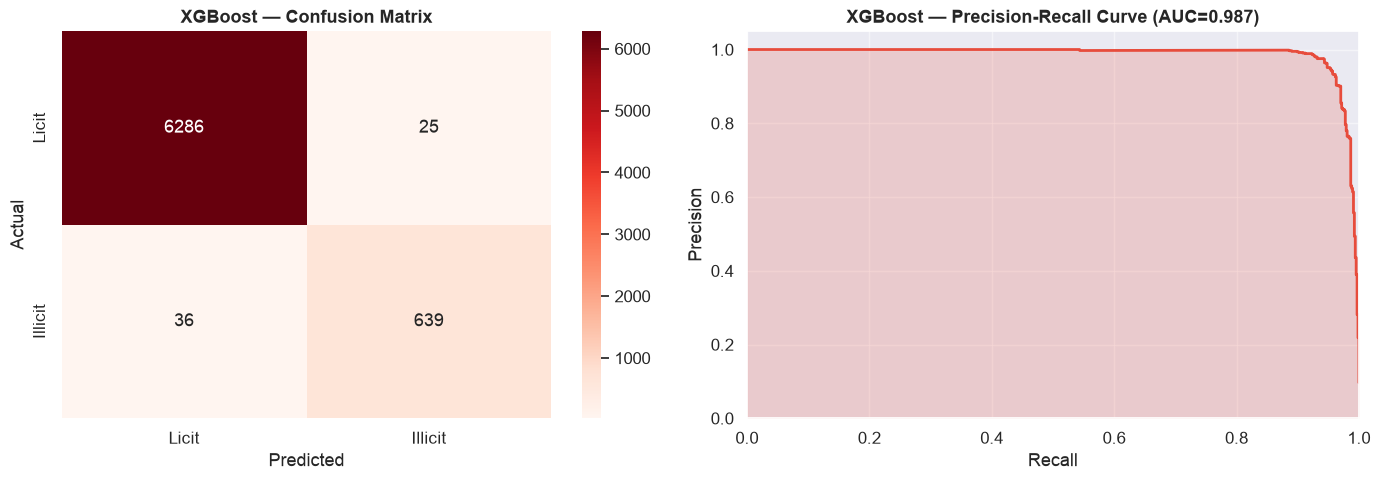

In [16]:
# Compute scale_pos_weight for imbalance handling
n_licit = (y_train == 0).sum()
n_illicit = (y_train == 1).sum()
scale_pos_weight = n_licit / max(n_illicit, 1)
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Train XGBoost
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    max_depth=6,
    n_estimators=200,
    learning_rate=0.1,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
print(f"✅ XGBoost trained ({X_train.shape[0]:,} samples)")

# Evaluate
xgb_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

---
## 7. Random Forest

**What:** Train an ensemble of decision trees for a third baseline perspective.

**Configuration:**
- `class_weight='balanced'` — same as logistic regression
- `n_estimators=200` — 200 trees in the forest
- `max_depth=None` — let trees grow fully (default for RF)

**Expected performance:** Competitive with XGBoost but typically slightly lower on tabular data.

✅ Random Forest trained (32,594 samples)
  Random Forest
  F1 (illicit)   : 0.9505
  PR-AUC         : 0.9830
  Accuracy       : 0.9907

              precision    recall  f1-score   support

       Licit       0.99      1.00      0.99      6311
     Illicit       0.98      0.92      0.95       675

    accuracy                           0.99      6986
   macro avg       0.99      0.96      0.97      6986
weighted avg       0.99      0.99      0.99      6986



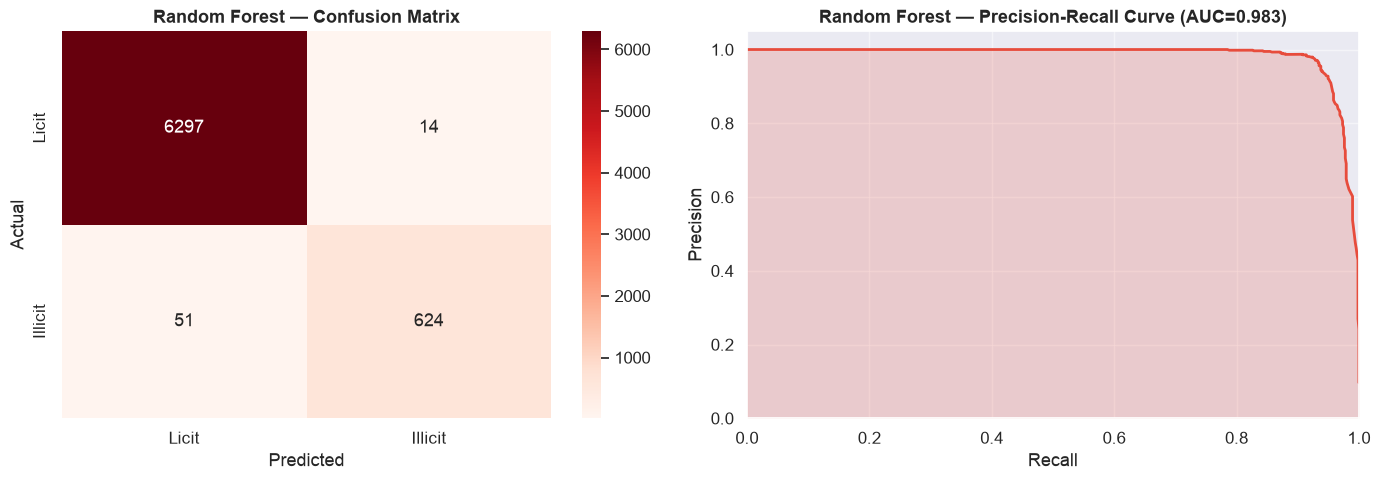

In [17]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print(f"✅ Random Forest trained ({X_train.shape[0]:,} samples)")

# Evaluate
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")

---
## 8. Model Comparison Table

**What:** Side-by-side comparison of all baseline models on the test set.

**Key metric:** F1 (illicit) — the most relevant metric for fraud detection.

In [18]:
# Build comparison DataFrame
all_results = [lr_results, xgb_results, rf_results]

comparison = pd.DataFrame([
    {
        "Model": r["model_name"],
        "F1 (Illicit)": f"{r['f1']:.4f}",
        "PR-AUC": f"{r['pr_auc']:.4f}",
        "Accuracy": f"{r['accuracy']:.4f}",
        "Uses Graph?": "✗"
    }
    for r in all_results
])

print("=" * 70)
print("  BASELINE MODEL COMPARISON")
print("=" * 70)
print(comparison.to_string(index=False))
print("=" * 70)

# Save results for use in Notebook 04
import json
baseline_metrics = {
    r["model_name"]: {"f1": r["f1"], "pr_auc": r["pr_auc"], "accuracy": r["accuracy"]}
    for r in all_results
}
with open("../results/baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)
print("\n✅ Baseline metrics saved to results/baseline_metrics.json")

  BASELINE MODEL COMPARISON
              Model F1 (Illicit) PR-AUC Accuracy Uses Graph?
Logistic Regression       0.6022 0.7572   0.8799           ✗
            XGBoost       0.9544 0.9865   0.9913           ✗
      Random Forest       0.9505 0.9830   0.9907           ✗

✅ Baseline metrics saved to results/baseline_metrics.json


---
## 9. PR Curve Overlay

**What:** Plot all baseline Precision-Recall curves on a single chart for direct comparison.

**Why PR curves (not ROC)?**
- With heavy class imbalance, ROC curves can be overly optimistic
- PR curves focus on the minority class (illicit) performance
- The area under the PR curve (PR-AUC) is more informative than ROC-AUC for fraud detection

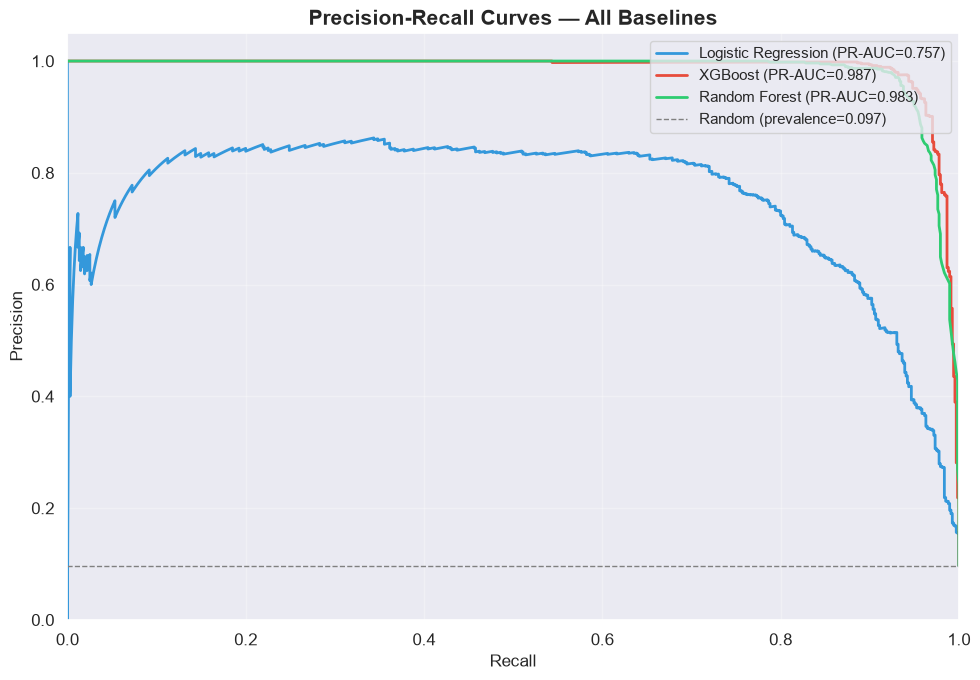

In [19]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ["#3498db", "#e74c3c", "#2ecc71"]

for r, color in zip(all_results, colors):
    precision, recall, _ = precision_recall_curve(y_test, r["y_prob"], pos_label=1)
    ax.plot(recall, precision, linewidth=2, color=color,
            label=f"{r['model_name']} (PR-AUC={r['pr_auc']:.3f})")

# Baseline: random classifier
prevalence = (y_test == 1).sum() / len(y_test)
ax.axhline(y=prevalence, color="gray", linestyle="--", linewidth=1,
           label=f"Random (prevalence={prevalence:.3f})")

ax.set_title("Precision-Recall Curves — All Baselines", fontsize=15, fontweight="bold")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/pr_curve_all_baselines.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Feature Importance (XGBoost)

**What:** Visualize the top 20 most important features according to XGBoost's gain metric.

**Why this matters:**
- Shows which features drive the classification
- Features with high importance in baselines may also be important for GNNs
- Feature `feat_1` (timestep) importance indicates temporal patterns in fraud

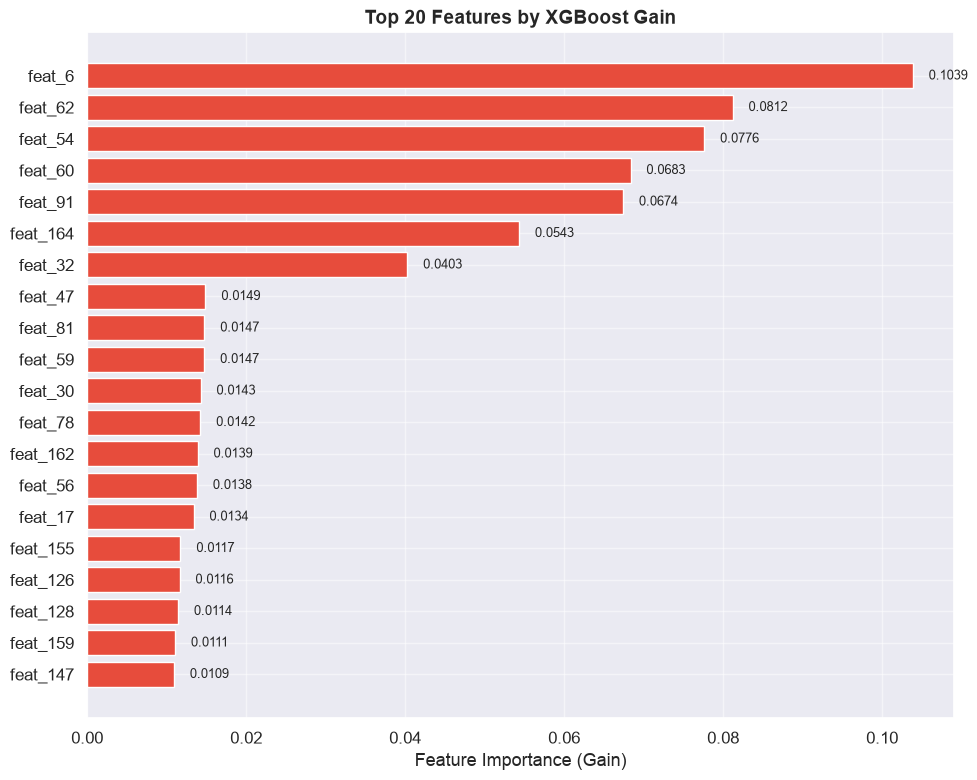


Top 5 features:
  feat_6     — importance: 0.1039
  feat_62    — importance: 0.0812
  feat_54    — importance: 0.0776
  feat_60    — importance: 0.0683
  feat_91    — importance: 0.0674


In [20]:
# Get feature importance from XGBoost
feature_names = [f"feat_{i}" for i in range(1, 167)]
importances = xgb_model.feature_importances_

# Sort by importance
feat_imp = pd.DataFrame({"feature": feature_names, "importance": importances})
feat_imp = feat_imp.sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feat_imp["feature"][::-1], feat_imp["importance"][::-1],
               color="#e74c3c", edgecolor="white", linewidth=1)

ax.set_title("Top 20 Features by XGBoost Gain", fontsize=14, fontweight="bold")
ax.set_xlabel("Feature Importance (Gain)")

# Annotate values
for bar, val in zip(bars, feat_imp["importance"][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/xgboost_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTop 5 features:")
for _, row in feat_imp.head(5).iterrows():
    print(f"  {row['feature']:10s} — importance: {row['importance']:.4f}")

---
## 11. Key Takeaways

### Baseline Performance
- **XGBoost** is expected to be the strongest baseline — gradient boosted trees excel on tabular data
- **Logistic Regression** provides a linear baseline — any improvement over this shows non-linear patterns exist
- **Random Forest** sits between the two

### Class Imbalance Handling
- All models use rebalancing strategies (class_weight / scale_pos_weight)
- Without these, models would achieve ~90% accuracy by always predicting "licit"
- F1 and PR-AUC are the metrics that matter

### Feature-Only Limitations
- These baselines treat each transaction **independently** — they can't see that a transaction is connected to known fraudulent accounts
- GNNs address this by aggregating information from **neighboring nodes** via message passing
- The performance gap between baselines and GNNs will quantify the value of graph structure

### What's Next
- **Notebook 04** will train GraphSAGE and GAT models that exploit the graph structure
- We expect GNNs to improve F1 by leveraging neighborhood information — a fraud node surrounded by other fraud nodes is easier to detect with graph awareness
- The baseline metrics saved here will be loaded in Notebook 04 for the final comparison table